In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


In [19]:
# Folder target di Google Drive (pastikan folder ini ada)
DRIVE_DATA_FOLDER = '/content/drive/MyDrive/datasetuts'

# Jika folder belum ada, buat
os.makedirs(DRIVE_DATA_FOLDER, exist_ok=True)

# Pilihan agregasi untuk visual bulanan: 'last' (recommended), 'mean', atau 'median'
AGG_METHOD = 'last'

# Nilai GDP 2023 (World Bank)
GDP_2023 = 5.049


In [20]:
# Ambil data harian IHSG untuk 2023
ihsg_2023 = yf.download("^JKSE", start="2023-01-01", end="2023-12-31", interval="1d")

# Reset index supaya Date jadi kolom biasa
ihsg_2023 = ihsg_2023.reset_index()

# Simpan raw CSV ke Drive
raw_path = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_realtime.csv')
ihsg_2023.to_csv(raw_path, index=False)
print("✅ Data IHSG 2023 disimpan di:", raw_path)

# Tampilkan 5 baris pertama
ihsg_2023.head()


/tmp/ipython-input-255933937.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ihsg_2023 = yf.download("^JKSE", start="2023-01-01", end="2023-12-31", interval="1d")
[*********************100%***********************]  1 of 1 completed

✅ Data IHSG 2023 disimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_realtime.csv


Price,Date,Close,High,Low,Open,Volume
Ticker,,^JKSE,^JKSE,^JKSE,^JKSE,^JKSE
0,2023-01-02,6850.983887,6856.889160,6823.479004,6850.740234,109645000
1,2023-01-03,6888.757812,6908.001953,6838.574219,6850.983887,156894900
2,2023-01-04,6813.238770,6900.603027,6813.238770,6888.798828,142541400
3,2023-01-05,6653.840820,6813.421875,6621.986816,6813.279785,180589300
4,2023-01-06,6684.558105,6708.637207,6598.645996,6653.759766,109855600


In [21]:
# Beberapa sumber mengembalikan MultiIndex columns; flatten kalau perlu
if isinstance(ihsg_2023.columns, pd.MultiIndex):
    ihsg_2023.columns = ['_'.join([str(c) for c in col if str(c) != '']).strip('_') for col in ihsg_2023.columns]
else:
    ihsg_2023.columns = [str(c) for c in ihsg_2023.columns]

# Pastikan kolom Date bertipe datetime
ihsg_2023['Date'] = pd.to_datetime(ihsg_2023['Date'])

# Temukan nama kolom yang berisi 'close' (case-insensitive)
close_candidates = [c for c in ihsg_2023.columns if 'close' in c.lower()]
if not close_candidates:
    raise RuntimeError("Tidak ditemukan kolom 'Close'. Cek ihsg_2023.columns:\n" + str(ihsg_2023.columns))

close_col = close_candidates[0]
print("Menggunakan kolom Close:", close_col)

# Konversi kolom Close ke numeric (aman)
ihsg_2023[close_col] = pd.to_numeric(ihsg_2023[close_col], errors='coerce')

# Tambah kolom Month / MonthNum untuk kemudahan
ihsg_2023['MonthNum'] = ihsg_2023['Date'].dt.month
ihsg_2023['Month'] = ihsg_2023['Date'].dt.month_name().str[:3]  # Jan, Feb, ...


Menggunakan kolom Close: Close_^JKSE


In [22]:
# Pilih metode agregasi
if AGG_METHOD == 'last':
    ihsg_monthly = ihsg_2023.groupby('MonthNum')[close_col].last()
elif AGG_METHOD == 'mean':
    ihsg_monthly = ihsg_2023.groupby('MonthNum')[close_col].mean()
elif AGG_METHOD == 'median':
    ihsg_monthly = ihsg_2023.groupby('MonthNum')[close_col].median()
else:
    raise ValueError("AGG_METHOD harus 'last', 'mean', atau 'median'")

# Pastikan index 1..12 urut, cast ke float dan isi NaN jika ada
ihsg_monthly = ihsg_monthly.reindex(range(1,13)).astype(float)
ihsg_monthly = ihsg_monthly.ffill().bfill()

# Buat DataFrame ringkasan yang rapi
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
summary_df = pd.DataFrame({
    'MonthNum': range(1,13),
    'Month': months,
    'Close': ihsg_monthly.values
})

# Simpan ringkasan ke Drive
summary_csv = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print("✅ Ringkasan IHSG bulanan tersimpan di:", summary_csv)

# Tampilkan ringkasan
display(summary_df)


✅ Ringkasan IHSG bulanan tersimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_summary.csv


,MonthNum,Month,Close
0,1,Jan,6839.341797
1,2,Feb,6843.238770
2,3,Mar,6805.276855
3,4,Apr,6915.715820
4,5,May,6633.261230
5,6,Jun,6661.878906
6,7,Jul,6931.358887
7,8,Aug,6953.259766
8,9,Sep,6939.892090
9,10,Oct,6752.210938


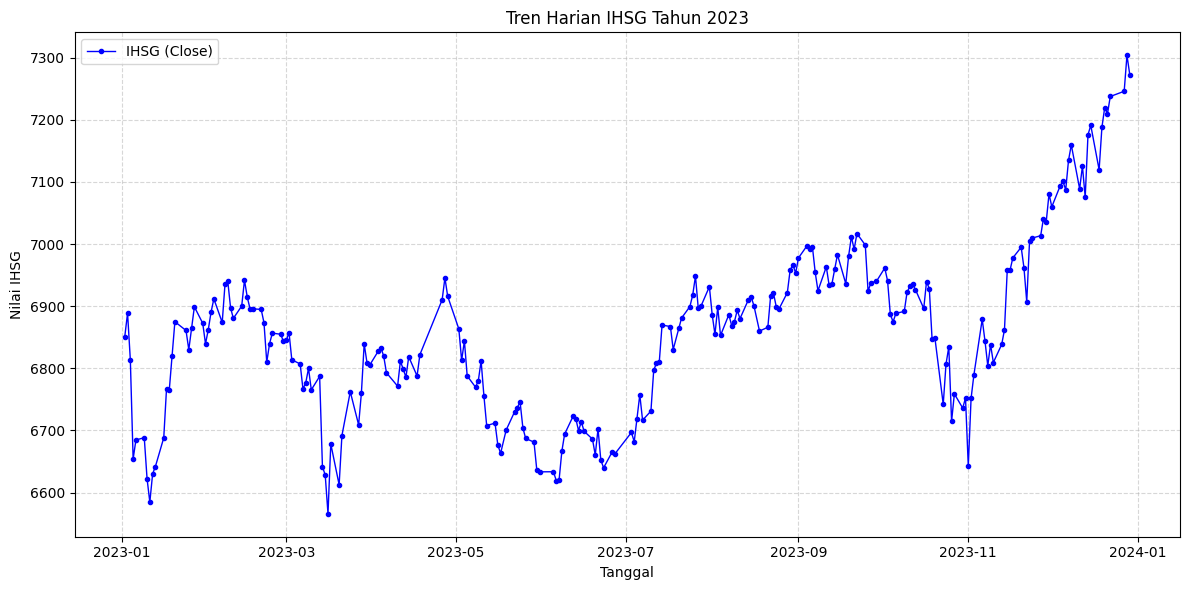

In [23]:
plt.figure(figsize=(12,6))
plt.plot(ihsg_2023['Date'], ihsg_2023[close_col], color='blue', marker='.', linewidth=1, label='IHSG (Close)')
plt.title('Tren Harian IHSG Tahun 2023')
plt.xlabel('Tanggal')
plt.ylabel('Nilai IHSG')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


✅ Grafik IHSG vs GDP tersimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_vs_GDP.png


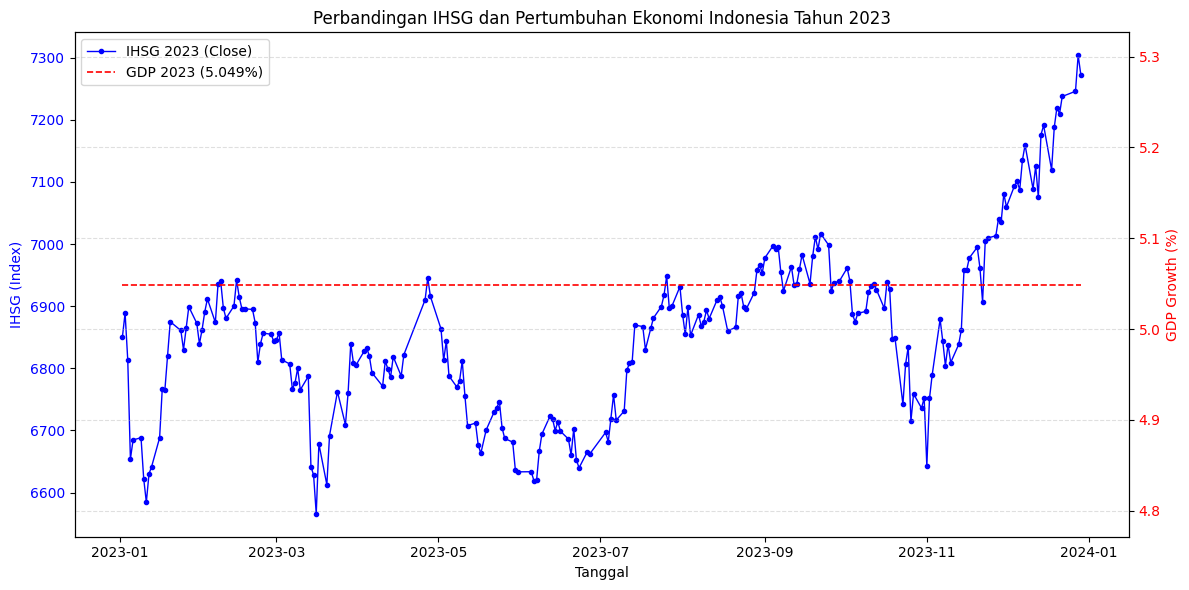

In [24]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Sumbu kiri: IHSG harian
ax1.plot(ihsg_2023['Date'], ihsg_2023[close_col], color='blue', marker='.', linewidth=1, label='IHSG 2023 (Close)')
ax1.set_xlabel('Tanggal')
ax1.set_ylabel('IHSG (Index)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Sumbu kanan: GDP 2023 (konstan)
ax2 = ax1.twinx()
ax2.plot(ihsg_2023['Date'], [GDP_2023]*len(ihsg_2023), color='red', linestyle='--', linewidth=1.2, label=f'GDP 2023 ({GDP_2023}%)')
ax2.set_ylabel('GDP Growth (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Perbandingan IHSG dan Pertumbuhan Ekonomi Indonesia Tahun 2023')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Simpan figure ke Drive
out_fig = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_vs_GDP.png')
fig.savefig(out_fig, dpi=300, bbox_inches='tight')
print("✅ Grafik IHSG vs GDP tersimpan di:", out_fig)

plt.show()


✅ Bar chart bulanan tersimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_monthly_bar.png


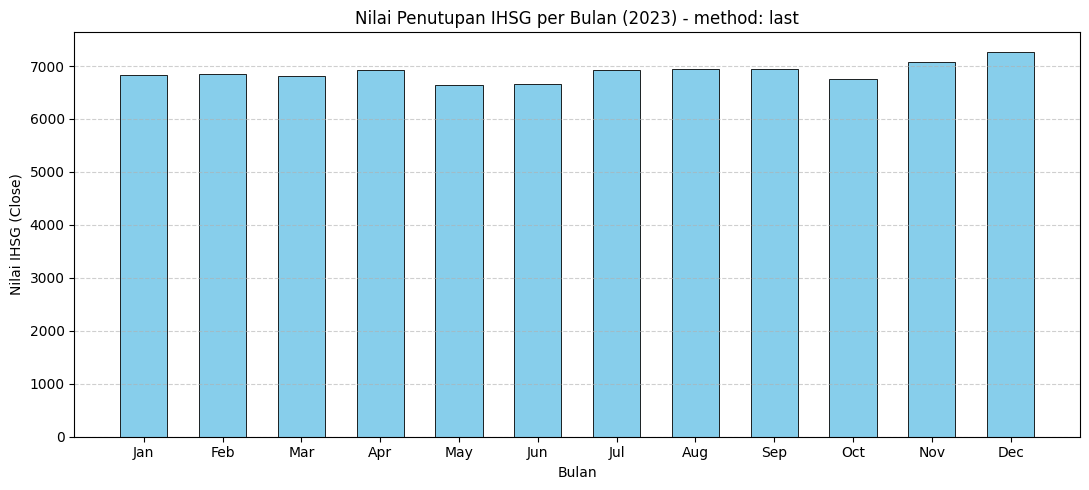

✅ Chart persentase perubahan tersimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_monthly_pct_change.png


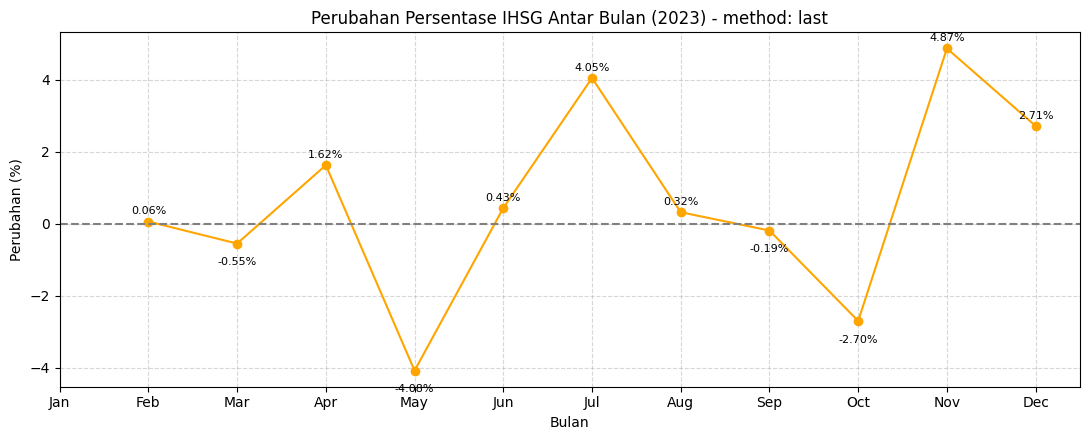

In [25]:
# Siapkan data
vals = ihsg_monthly.to_numpy(dtype=float).flatten().tolist()
x = np.arange(len(months))
monthly_pct_change = pd.Series(vals).pct_change() * 100

# Bar chart bulanan
plt.figure(figsize=(11,5))
plt.bar(x, vals, color='skyblue', edgecolor='k', linewidth=0.6, width=0.6)
plt.xticks(x, months)
plt.title(f'Nilai Penutupan IHSG per Bulan (2023) - method: {AGG_METHOD}')
plt.xlabel('Bulan')
plt.ylabel('Nilai IHSG (Close)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Simpan bar chart
bar_path = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_monthly_bar.png')
plt.tight_layout()
plt.savefig(bar_path, dpi=300, bbox_inches='tight')
print("✅ Bar chart bulanan tersimpan di:", bar_path)
plt.show()

# Persentase perubahan antar bulan dengan anotasi
plt.figure(figsize=(11,4.5))
plt.plot(x, monthly_pct_change.values, marker='o', color='orange', linewidth=1.5)
plt.xticks(x, months)
plt.axhline(0, color='gray', linestyle='--')
plt.title(f'Perubahan Persentase IHSG Antar Bulan (2023) - method: {AGG_METHOD}')
plt.xlabel('Bulan')
plt.ylabel('Perubahan (%)')
plt.grid(True, linestyle='--', alpha=0.5)

# tambahkan label angka di atas titik
for i, v in enumerate(monthly_pct_change.values):
    if not np.isnan(v):
        plt.text(i, v + (0.2 if v >= 0 else -0.6), f"{v:.2f}%", ha='center', fontsize=8, color='black')

# Simpan
pct_path = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_monthly_pct_change.png')
plt.tight_layout()
plt.savefig(pct_path, dpi=300, bbox_inches='tight')
print("✅ Chart persentase perubahan tersimpan di:", pct_path)
plt.show()


✅ Heatmap korelasi tersimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_corr_heatmap.png


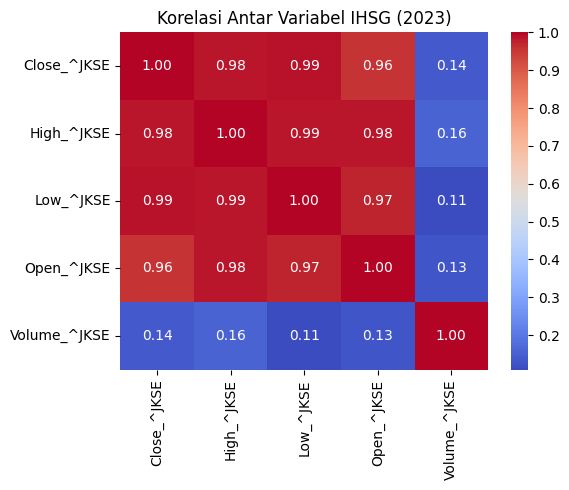

✅ Histogram tersimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_histogram.png


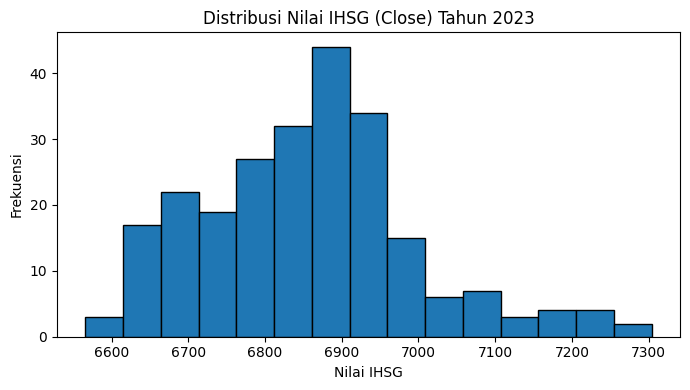

In [26]:
# Heatmap korelasi antar variabel numerik (Open, High, Low, Close, Volume)
# Temukan nama kolom yang cocok (open/high/low/volume)
num_cols = [c for c in ihsg_2023.columns if any(k in c.lower() for k in ['open','high','low','close','volume'])]
corr_df = ihsg_2023[num_cols].apply(pd.to_numeric, errors='coerce').corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Antar Variabel IHSG (2023)')
plt.tight_layout()
heat_path = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_corr_heatmap.png')
plt.savefig(heat_path, dpi=300, bbox_inches='tight')
print("✅ Heatmap korelasi tersimpan di:", heat_path)
plt.show()

# Histogram distribusi Close
plt.figure(figsize=(7,4))
plt.hist(ihsg_2023[close_col].dropna(), bins=15, edgecolor='k')
plt.title('Distribusi Nilai IHSG (Close) Tahun 2023')
plt.xlabel('Nilai IHSG')
plt.ylabel('Frekuensi')
hist_path = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_histogram.png')
plt.tight_layout()
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
print("✅ Histogram tersimpan di:", hist_path)
plt.show()


In [27]:
# Statistik ringkas
avg_ihsg = float(ihsg_2023[close_col].mean())
max_ihsg = float(ihsg_2023[close_col].max())
min_ihsg = float(ihsg_2023[close_col].min())
change_net = ( (ihsg_2023[close_col].iloc[-1] - ihsg_2023[close_col].iloc[0]) / ihsg_2023[close_col].iloc[0] ) * 100

summary_stats = {
    'Rata-rata_IHSG_2023': round(avg_ihsg,2),
    'Tertinggi_IHSG_2023': round(max_ihsg,2),
    'Terendah_IHSG_2023': round(min_ihsg,2),
    'Kenaikan_Bersih_%_2023': round(change_net,2),
    'GDP_2023_%': GDP_2023
}
print("📌 Ringkasan Statistik 2023:")
for k,v in summary_stats.items():
    print(f" - {k}: {v}")

# Simpan summary ke csv
summary_stats_df = pd.DataFrame([summary_stats])
summary_stats_csv = os.path.join(DRIVE_DATA_FOLDER, 'IHSG_2023_summary_stats.csv')
summary_stats_df.to_csv(summary_stats_csv, index=False)
print("✅ Statistik ringkasan tersimpan di:", summary_stats_csv)


📌 Ringkasan Statistik 2023:
 - Rata-rata_IHSG_2023: 6856.96
 - Tertinggi_IHSG_2023: 7303.89
 - Terendah_IHSG_2023: 6565.73
 - Kenaikan_Bersih_%_2023: 6.16
 - GDP_2023_%: 5.049
✅ Statistik ringkasan tersimpan di: /content/drive/MyDrive/datasetuts/IHSG_2023_summary_stats.csv


✅ Semua gambar tersimpan di: /content/drive/MyDrive/datasetuts


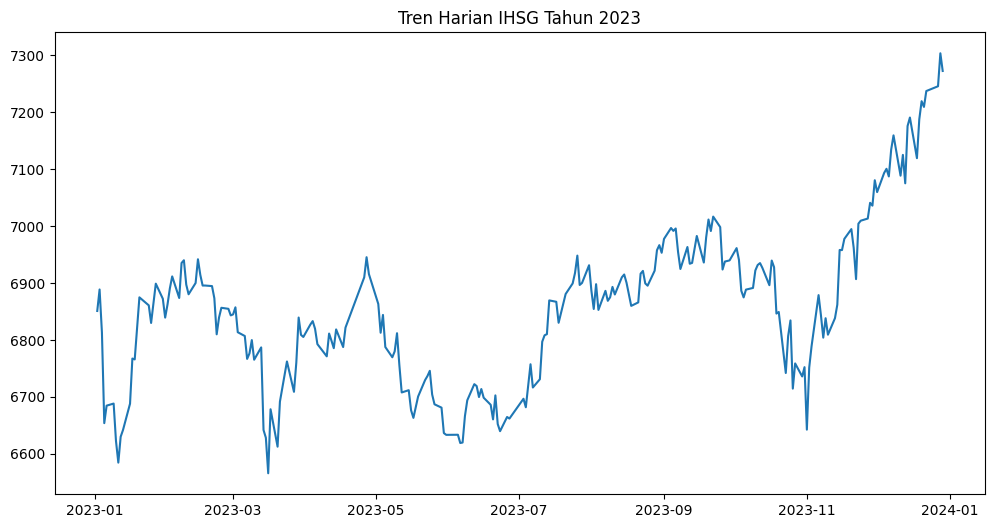

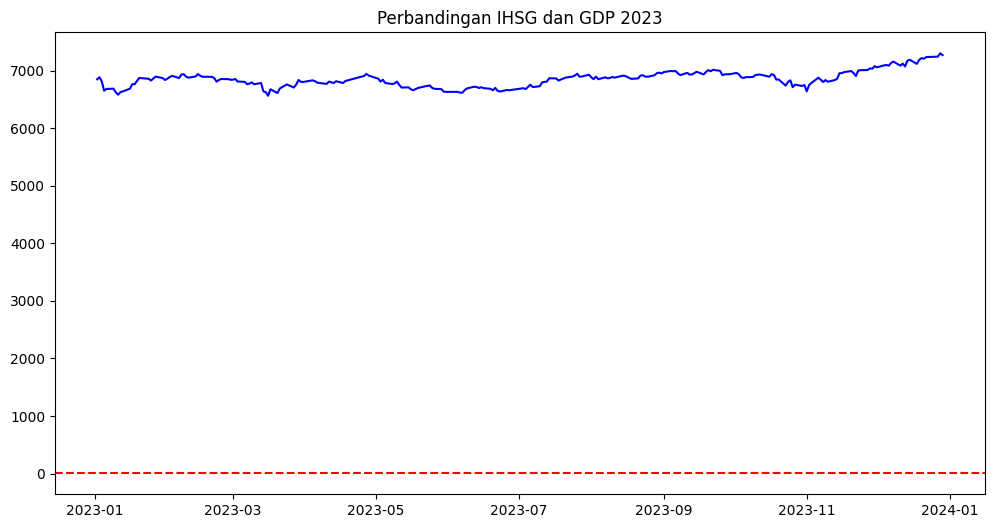

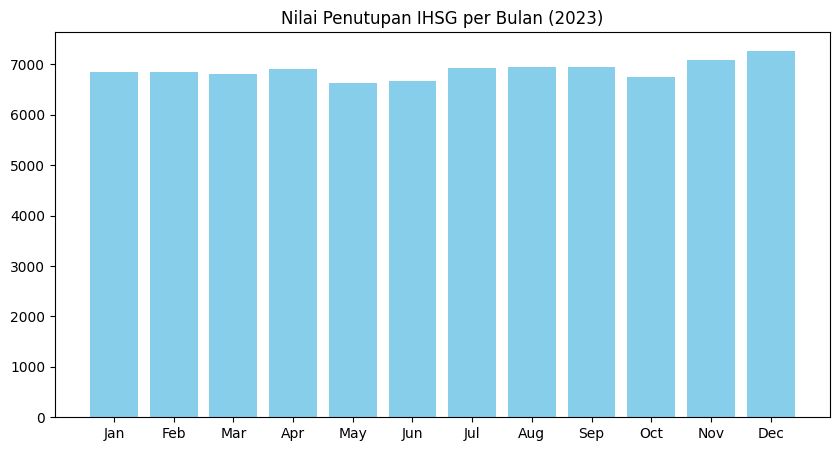

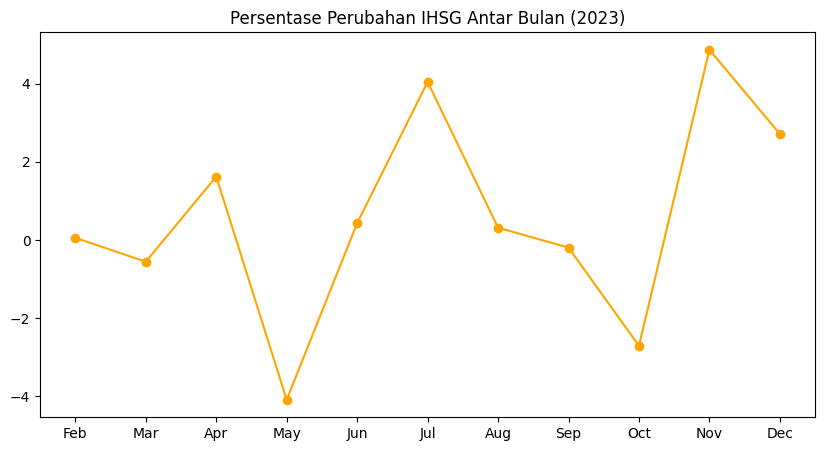

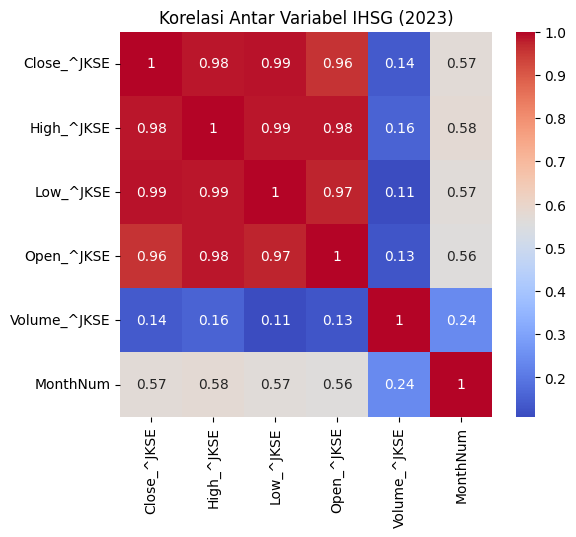

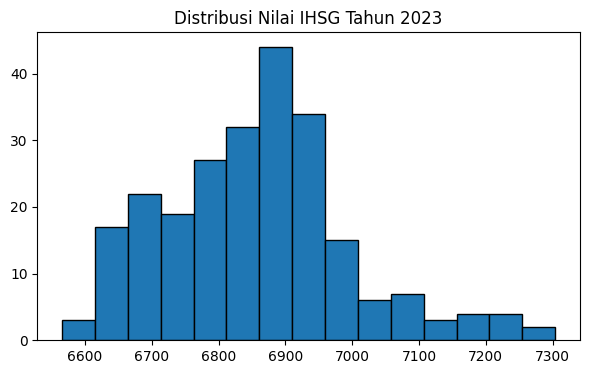

In [28]:
# Simpan semua grafik ke folder datasetuts (kalau belum)
from matplotlib import pyplot as plt
import os

drive_path = '/content/drive/MyDrive/datasetuts'
os.makedirs(drive_path, exist_ok=True)

# Simpan ulang semua figure (jalankan setelah plotting)
plt.figure(figsize=(12,6))
plt.plot(ihsg_2023['Date'], ihsg_2023[close_col])
plt.title('Tren Harian IHSG Tahun 2023')
plt.savefig(os.path.join(drive_path, 'IHSG_2023_tren_harian.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(12,6))
plt.plot(ihsg_2023['Date'], ihsg_2023[close_col], color='blue')
plt.axhline(y=GDP_2023, color='red', linestyle='--')
plt.title('Perbandingan IHSG dan GDP 2023')
plt.savefig(os.path.join(drive_path, 'IHSG_2023_vs_GDP.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(10,5))
plt.bar(summary_df['Month'], summary_df['Close'], color='skyblue')
plt.title('Nilai Penutupan IHSG per Bulan (2023)')
plt.savefig(os.path.join(drive_path, 'IHSG_2023_barchart.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(10,5))
plt.plot(summary_df['Month'], summary_df['Close'].pct_change()*100, color='orange', marker='o')
plt.title('Persentase Perubahan IHSG Antar Bulan (2023)')
plt.savefig(os.path.join(drive_path, 'IHSG_2023_pctchange.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(6,5))
sns.heatmap(ihsg_2023.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Variabel IHSG (2023)')
plt.savefig(os.path.join(drive_path, 'IHSG_2023_heatmap.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(7,4))
plt.hist(ihsg_2023[close_col], bins=15, edgecolor='k')
plt.title('Distribusi Nilai IHSG Tahun 2023')
plt.savefig(os.path.join(drive_path, 'IHSG_2023_histogram.png'), dpi=300, bbox_inches='tight')

print("✅ Semua gambar tersimpan di:", drive_path)


In [29]:
import os
print(os.listdir('/content/drive/MyDrive/datasetuts'))


['JKSE_20250101_20251027.csv', 'Metadata_Indicator_API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_130026.csv', 'Metadata_Country_API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_130026.csv', 'API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_130026.csv', 'Jakarta Stock Exchange Composite Index Historical Data.csv', 'IHSG_2023_summary.csv', 'IHSG_2023_vs_GDP_figure.png', 'IHSG_2023_realtime.csv', 'IHSG_2023_vs_GDP.png', 'IHSG_2023_monthly_bar.png', 'IHSG_2023_monthly_pct_change.png', 'IHSG_2023_corr_heatmap.png', 'IHSG_2023_histogram.png', 'IHSG_2023_summary_stats.csv', 'IHSG_2023_tren_harian.png', 'IHSG_2023_barchart.png', 'IHSG_2023_pctchange.png', 'IHSG_2023_heatmap.png']
